# Chronos

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from chronos import BaseChronosPipeline
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

c:\Users\Federico\DesktopW\patchAliasing\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from chronos import BaseChronosPipeline, Chronos2Pipeline

pipeline_bolt_tiny = BaseChronosPipeline.from_pretrained(
    "amazon/chronos-bolt-tiny",
    device_map="cpu",
)

pipeline_bolt_small = BaseChronosPipeline.from_pretrained(
    "amazon/chronos-bolt-small",
    device_map="cpu",
)

pipeline_chronos = BaseChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map="cpu",
)

pipeline_chronos2 = Chronos2Pipeline.from_pretrained(
    "amazon/chronos-2",
    device_map="cpu",
)

In [3]:
pipeline = pipeline_bolt_tiny

## Model

In [4]:
model = pipeline.model

print(type(model))

<class 'chronos.chronos_bolt.ChronosBoltModelForForecasting'>


In [5]:
pre_transformer_modules = []
encoder_modules = []
decoder_modules = []
post_transformer_modules = []

modules = []
for name, module in model.named_modules():
    modules.append((name, module))


In [6]:
for name, module in modules:
    if "encoder" not in name:
        pre_transformer_modules.append((name, module))
        modules.remove((name, module))
    else:
        break

i = 0
for name, module in pre_transformer_modules:
    if i == 0:
        print(f"Pre-transformer modules: {type(module)}")
    else:
        print(f"{i}: {name}: {type(module)}")
    i += 1

Pre-transformer modules: <class 'chronos.chronos_bolt.ChronosBoltModelForForecasting'>
1: input_patch_embedding: <class 'chronos.chronos_bolt.ResidualBlock'>
2: input_patch_embedding.hidden_layer: <class 'torch.nn.modules.linear.Linear'>
3: input_patch_embedding.output_layer: <class 'torch.nn.modules.linear.Linear'>
4: patch: <class 'chronos.chronos_bolt.Patch'>


In [7]:
for name, module in modules:
    if "encoder" in name and "decoder" not in name:
        encoder_modules.append((name, module))
        modules.remove((name, module))
        
i = 0
for name, module in encoder_modules:
    if i == 0:
        print(f"Encoder modules: {type(module)}")
    else:
        print(f"{i}: {name}: {type(module)}")
    i += 1

Encoder modules: <class 'transformers.models.t5.modeling_t5.T5Stack'>
1: encoder.block.0: <class 'transformers.models.t5.modeling_t5.T5Block'>
2: encoder.block.0.layer.0: <class 'transformers.models.t5.modeling_t5.T5LayerSelfAttention'>
3: encoder.block.0.layer.0.SelfAttention.q: <class 'torch.nn.modules.linear.Linear'>
4: encoder.block.0.layer.0.SelfAttention.v: <class 'torch.nn.modules.linear.Linear'>
5: encoder.block.0.layer.0.SelfAttention.relative_attention_bias: <class 'torch.nn.modules.sparse.Embedding'>
6: encoder.block.0.layer.0.dropout: <class 'torch.nn.modules.dropout.Dropout'>
7: encoder.block.0.layer.1.DenseReluDense: <class 'transformers.models.t5.modeling_t5.T5DenseActDense'>
8: encoder.block.0.layer.1.DenseReluDense.wo: <class 'torch.nn.modules.linear.Linear'>
9: encoder.block.0.layer.1.DenseReluDense.act: <class 'torch.nn.modules.activation.ReLU'>
10: encoder.block.0.layer.1.dropout: <class 'torch.nn.modules.dropout.Dropout'>
11: encoder.block.1.layer: <class 'torch.nn

In [8]:
for name, module in modules:
    if "decoder" in name:
        decoder_modules.append((name, module))
        modules.remove((name, module))

i = 0
for name, module in decoder_modules:
    if i == 0:
        print(f"Decoder modules: {type(module)}")
    else:
        print(f"{i}: {name}: {type(module)}")
    i += 1

Decoder modules: <class 'transformers.models.t5.modeling_t5.T5Stack'>
1: decoder.block.0: <class 'transformers.models.t5.modeling_t5.T5Block'>
2: decoder.block.0.layer.0: <class 'transformers.models.t5.modeling_t5.T5LayerSelfAttention'>
3: decoder.block.0.layer.0.SelfAttention.q: <class 'torch.nn.modules.linear.Linear'>
4: decoder.block.0.layer.0.SelfAttention.v: <class 'torch.nn.modules.linear.Linear'>
5: decoder.block.0.layer.0.SelfAttention.relative_attention_bias: <class 'torch.nn.modules.sparse.Embedding'>
6: decoder.block.0.layer.0.dropout: <class 'torch.nn.modules.dropout.Dropout'>
7: decoder.block.0.layer.1.EncDecAttention: <class 'transformers.models.t5.modeling_t5.T5Attention'>
8: decoder.block.0.layer.1.EncDecAttention.k: <class 'torch.nn.modules.linear.Linear'>
9: decoder.block.0.layer.1.EncDecAttention.o: <class 'torch.nn.modules.linear.Linear'>
10: decoder.block.0.layer.1.dropout: <class 'torch.nn.modules.dropout.Dropout'>
11: decoder.block.0.layer.2.DenseReluDense: <clas

In [9]:
for name, module in modules[20:]:
    if "encoder" not in name and "decoder" not in name:
        post_transformer_modules.append((name, module))

i = 0
for name, module in post_transformer_modules:
    if i == 0:
        print(f"Post-transformer modules: {type(module)}")
    else:
        print(f"{i}: {name}: {type(module)}")
    i += 1

Post-transformer modules: <class 'chronos.chronos_bolt.ResidualBlock'>
1: output_patch_embedding.dropout: <class 'torch.nn.modules.dropout.Dropout'>
2: output_patch_embedding.hidden_layer: <class 'torch.nn.modules.linear.Linear'>
3: output_patch_embedding.act: <class 'torch.nn.modules.activation.ReLU'>
4: output_patch_embedding.output_layer: <class 'torch.nn.modules.linear.Linear'>
5: output_patch_embedding.residual_layer: <class 'torch.nn.modules.linear.Linear'>


## Embeddings

In [10]:
captured = {
    "patches": None, # This will be a list of tensors, one for each patch, containing the raw pixel values of the patch.
    "patch_embeddings": None, # This will be a list of tensors, one for each patch, containing the embeddings of the patches after the patch embedding layer.
    "encoder_inputs": None, # This will be a list of tensors, one for each patch, containing the inputs to the encoder after the positional encoding and patch embedding layers.
}

### Hooks

In [11]:
# Hook is a function that will be called every time the module/layer is called. 
# Using PyTorch forward, hooks to “spy on” intermediate values inside a neural network while it runs.


# Dictionary to store captured tensors
captured = {}
# List to keep hook handles
hooks = []

# ============================================================
# SAFE EXTRACTOR
# ============================================================

def to_cpu(x):

    if torch.is_tensor(x):
        return x.detach().cpu()

    if isinstance(x, tuple):
        for item in x:
            if torch.is_tensor(item):
                return item.detach().cpu()

    return x


In [12]:
# ============================================================
# 1. PATCH MODULE OUTPUT
# ============================================================
# NOTE:
# This is NOT raw values.
# It is Chronos internal patch representation.
# Often includes masks/padding/NaN handling.
# ============================================================

def patch_hook(module, inputs, outputs):

    captured["patch"] = to_cpu(outputs)

hooks.append(
    model.patch.register_forward_hook(patch_hook)
)

In [13]:
# ============================================================
# 2. INSTANCE NORMALIZATION
# ============================================================

def norm_hook(module, inputs, outputs):

    captured["normalized"] = to_cpu(outputs)

hooks.append(
    model.instance_norm.register_forward_hook(norm_hook)
)

In [14]:

# ============================================================
# 3. INPUT TO EMBEDDING NETWORK
# ============================================================
# IMPORTANT:
# This is the TRUE tensor entering the embedding MLP.
# ============================================================

def embedding_input_hook(module, inputs):

    if len(inputs) > 0:
        captured["embedding_input"] = to_cpu(inputs[0])

hooks.append(
    model.input_patch_embedding.hidden_layer.register_forward_pre_hook(
        embedding_input_hook
    )
)

In [15]:
# ============================================================
# 4. HIDDEN LAYER OUTPUT
# ============================================================

def hidden_hook(module, inputs, outputs):

    captured["hidden"] = to_cpu(outputs)

hooks.append(
    model.input_patch_embedding.hidden_layer.register_forward_hook(
        hidden_hook
    )
)

In [16]:
# ============================================================
# 5. RELU ACTIVATIONS
# ============================================================

def relu_hook(module, inputs, outputs):

    captured["relu"] = to_cpu(outputs)

hooks.append(
    model.input_patch_embedding.act.register_forward_hook(
        relu_hook
    )
)

In [17]:
# ============================================================
# 6. OUTPUT LINEAR LAYER
# ============================================================
# Nonlinear pathway BEFORE residual merge
# ============================================================

def output_hook(module, inputs, outputs):

    captured["output_linear"] = to_cpu(outputs)

hooks.append(
    model.input_patch_embedding.output_layer.register_forward_hook(
        output_hook
    )
)

In [18]:
# ============================================================
# 7. RESIDUAL PATHWAY
# ============================================================

def residual_hook(module, inputs, outputs):

    captured["residual"] = to_cpu(outputs)

hooks.append(
    model.input_patch_embedding.residual_layer.register_forward_hook(
        residual_hook
    )
)

In [19]:
# ============================================================
# 8. FINAL PATCH EMBEDDINGS
# ============================================================
# Final transformer tokens
# ============================================================

def final_embedding_hook(module, inputs, outputs):

    captured["final_embedding"] = to_cpu(outputs)

hooks.append(
    model.input_patch_embedding.register_forward_hook(
        final_embedding_hook
    )
)

In [20]:
# =========================================================
# REMOVE ALL HOOKS
# =========================================================

def remove_hooks():
    for h in hooks:
        h.remove()

### Parameters Testing

In [21]:
# ============================================================
# INPUT
# ============================================================

series = torch.tensor([
    11.0, 1.2, 1.4, 1.1,
    0.9, 1.3, 1.5, 1.7,
    1.8, 1.6, 1.4, 1.2,
    1.1, 1.0, 0.8, 0.7,
    0.9, 1.1, 1.3, 1.5,
    1.7, 1.9, 2.0, 1.8,
    1.6, 1.4, 1.2, 1.0,
], dtype=torch.float32)

In [22]:
# ============================================================
# RUN THROUGH PIPELINE
# ============================================================

with torch.no_grad():

    forecast = pipeline.predict(
        series,
        prediction_length=8,
    )


# ============================================================
# REMOVE ALL HOOKS
# ============================================================

remove_hooks()

In [23]:
# ============================================================
# RETRIEVE CAPTURED TENSORS
# ============================================================

patch = captured["patch"]

normalized = captured["normalized"]

embedding_input = captured["embedding_input"]

hidden = captured["hidden"]

relu = captured["relu"]

output_linear = captured["output_linear"]

residual = captured["residual"]

final_embedding = captured["final_embedding"]


0. INPUT SERIES
Shape: torch.Size([28])
Value 0: 11.0
Value 1: 1.2000000476837158
Value 2: 1.399999976158142
Value 3: 1.100000023841858
Value 4: 0.8999999761581421
Value 5: 1.2999999523162842
Value 6: 1.5
Value 7: 1.7000000476837158
Value 8: 1.7999999523162842
Value 9: 1.600000023841858
Value 10: 1.399999976158142
Value 11: 1.2000000476837158
Value 12: 1.100000023841858
Value 13: 1.0
Value 14: 0.800000011920929
Value 15: 0.699999988079071
Value 16: 0.8999999761581421
Value 17: 1.100000023841858
Value 18: 1.2999999523162842
Value 19: 1.5
Value 20: 1.7000000476837158
Value 21: 1.899999976158142
Value 22: 2.0
Value 23: 1.7999999523162842
Value 24: 1.600000023841858
Value 25: 1.399999976158142
Value 26: 1.2000000476837158
Value 27: 1.0

1. PATCH MODULE OUTPUT
Shape: torch.Size([1, 2, 16])

Patch 0:
tensor([nan, nan, nan, nan, 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

Patch 1:
tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

2. NORMALIZED SERIES
Shape: torc

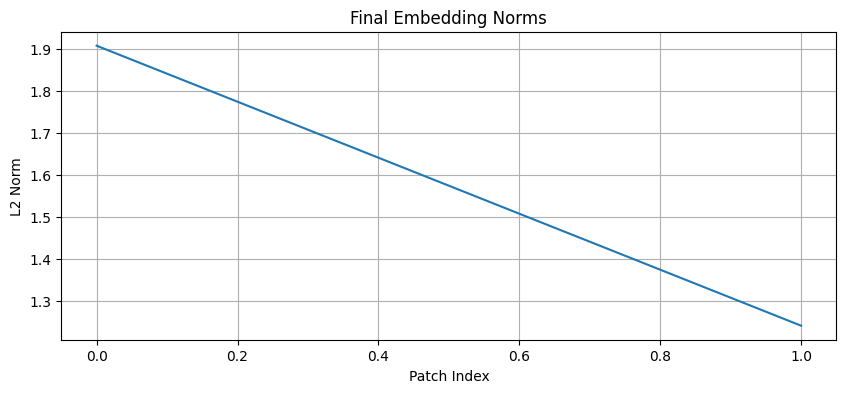

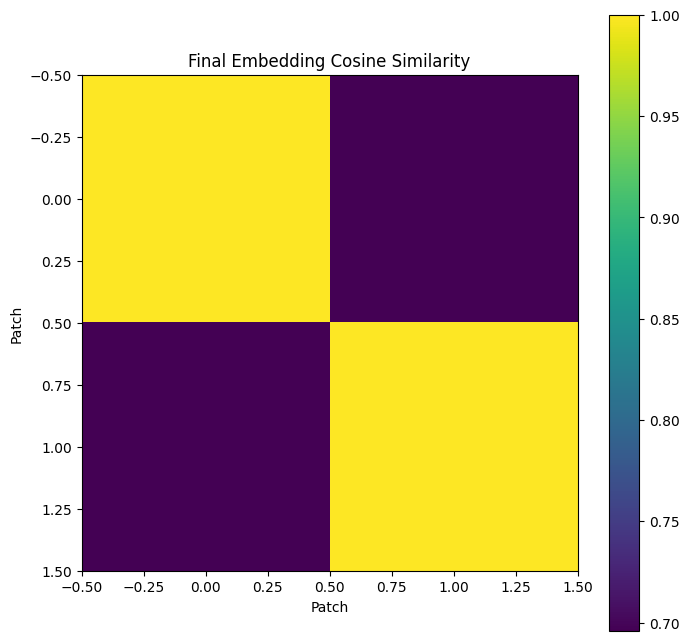

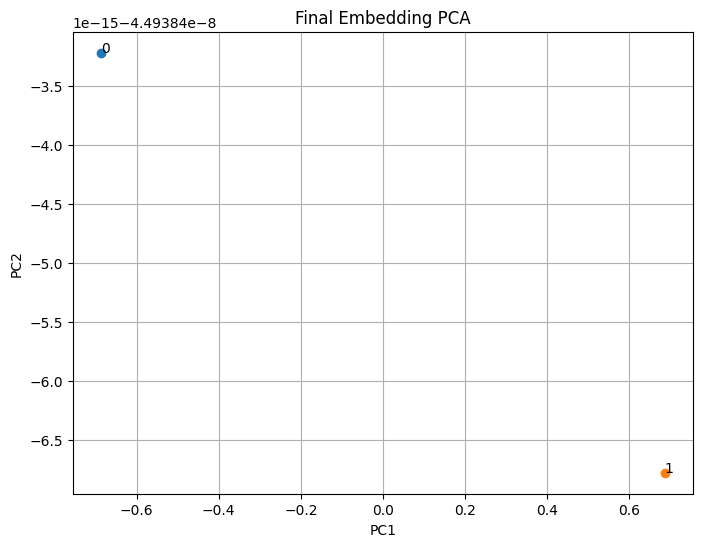

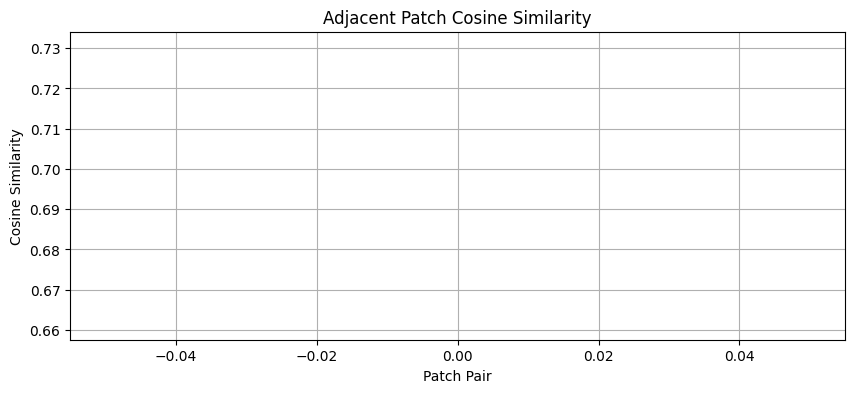

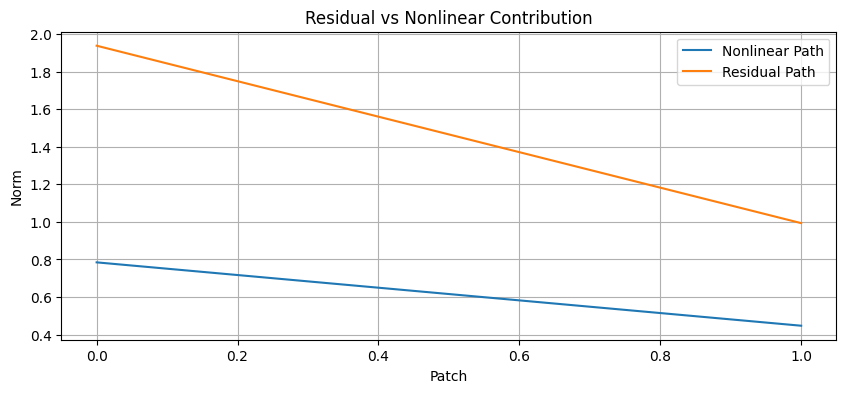


FORECAST
tensor([[[0.9210, 0.8734, 0.8585, 0.8479, 0.8512, 0.8456, 0.8253, 0.8189],
         [0.9975, 0.9725, 0.9534, 0.9451, 0.9605, 0.9578, 0.9431, 0.9278],
         [1.0440, 1.0196, 1.0063, 0.9922, 1.0201, 1.0202, 1.0006, 0.9854],
         [1.0723, 1.0450, 1.0347, 1.0266, 1.0632, 1.0598, 1.0358, 1.0199],
         [1.0926, 1.0671, 1.0590, 1.0562, 1.1004, 1.0989, 1.0687, 1.0522],
         [1.1172, 1.0887, 1.0884, 1.0912, 1.1478, 1.1505, 1.1167, 1.0987],
         [1.1578, 1.1311, 1.1384, 1.1575, 1.2280, 1.2388, 1.2110, 1.1932],
         [1.2558, 1.2482, 1.2843, 1.3409, 1.4504, 1.4962, 1.4837, 1.4698],
         [1.7405, 1.8416, 1.9821, 2.1120, 2.3252, 2.4340, 2.4791, 2.5053]]])


In [24]:
# ============================================================
# 0. INPUT SERIES
# ============================================================

print("\n================================================")
print("0. INPUT SERIES")
print("================================================")

print("Shape:", series.shape)

for i in range(series.shape[0]):

    print(f"Value {i}: {series[i].item()}")


# ============================================================
# 1. PATCH MODULE OUTPUT
# ============================================================

print("\n================================================")
print("1. PATCH MODULE OUTPUT")
print("================================================")

print("Shape:", patch.shape)

for i in range(patch.shape[1]):

    print(f"\nPatch {i}:")

    print(patch[0, i])


# ============================================================
# 2. NORMALIZED SERIES
# ============================================================

print("\n================================================")
print("2. NORMALIZED SERIES")
print("================================================")

print("Shape:", normalized.shape)

for i in range(normalized.shape[1]):

    print(f"\nNormalized Value {i}:")

    print(normalized[0, i])


# ============================================================
# 3. INPUT TO EMBEDDING NETWORK
# ============================================================

print("\n================================================")
print("3. EMBEDDING INPUT")
print("================================================")

print("Shape:", embedding_input.shape)

for i in range(embedding_input.shape[1]):

    print(f"\nEmbedding Input {i}:")

    print(embedding_input[0, i])


# ============================================================
# 4. HIDDEN FEATURES
# ============================================================

print("\n================================================")
print("4. HIDDEN FEATURES")
print("================================================")

print("Shape:", hidden.shape)

for i in range(hidden.shape[1]):

    print(f"\nHidden Feature {i}:")

    print(hidden[0, i])


# ============================================================
# 5. RELU ACTIVATIONS
# ============================================================

print("\n================================================")
print("5. RELU ACTIVATIONS")
print("================================================")

print("Shape:", relu.shape)

for i in range(relu.shape[1]):

    print(f"\nReLU Activation {i}:")

    print(relu[0, i])


# ============================================================
# 6. OUTPUT LINEAR LAYER
# ============================================================

print("\n================================================")
print("6. OUTPUT LINEAR")
print("================================================")

print("Shape:", output_linear.shape)

for i in range(output_linear.shape[1]):

    print(f"\nOutput Linear {i}:")

    print(output_linear[0, i])


# ============================================================
# 7. RESIDUAL PATHWAY
# ============================================================

print("\n================================================")
print("7. RESIDUAL PATHWAY")
print("================================================")

print("Shape:", residual.shape)

for i in range(residual.shape[1]):

    print(f"\nResidual {i}:")

    print(residual[0, i])


# ============================================================
# 8. FINAL PATCH EMBEDDINGS
# ============================================================

print("\n================================================")
print("8. FINAL PATCH EMBEDDINGS")
print("================================================")

print("Shape:", final_embedding.shape)

batch, num_patches, d_model = final_embedding.shape

print("\nNum patches:", num_patches)

print("Embedding dim:", d_model)

for i in range(num_patches):

    print(f"\nFinal Embedding {i}:")

    print(final_embedding[0, i])


# ============================================================
# EMBEDDING NORMS
# ============================================================

norms = torch.norm(final_embedding[0], dim=-1)

plt.figure(figsize=(10, 4))

plt.plot(norms.numpy())

plt.title("Final Embedding Norms")

plt.xlabel("Patch Index")

plt.ylabel("L2 Norm")

plt.grid()

plt.show()


# ============================================================
# COSINE SIMILARITY
# ============================================================

X = final_embedding[0].numpy()

sim = cosine_similarity(X)

plt.figure(figsize=(8, 8))

plt.imshow(sim)

plt.colorbar()

plt.title("Final Embedding Cosine Similarity")

plt.xlabel("Patch")

plt.ylabel("Patch")

plt.show()


# ============================================================
# PCA
# ============================================================

pca = PCA(n_components=2)

Y = pca.fit_transform(X)

plt.figure(figsize=(8, 6))

for i in range(num_patches):

    plt.scatter(Y[i, 0], Y[i, 1])

    plt.text(Y[i, 0], Y[i, 1], str(i))

plt.title("Final Embedding PCA")

plt.xlabel("PC1")

plt.ylabel("PC2")

plt.grid()

plt.show()


# ============================================================
# TEMPORAL ADJACENT SIMILARITY
# ============================================================

adjacent = []

for i in range(num_patches - 1):

    a = X[i]

    b = X[i + 1]

    cos = np.dot(a, b) / (
        np.linalg.norm(a)
        * np.linalg.norm(b)
    )

    adjacent.append(cos)

plt.figure(figsize=(10, 4))

plt.plot(adjacent)

plt.title("Adjacent Patch Cosine Similarity")

plt.xlabel("Patch Pair")

plt.ylabel("Cosine Similarity")

plt.grid()

plt.show()


# ============================================================
# RESIDUAL VS NONLINEAR CONTRIBUTION
# ============================================================

nonlinear_norm = torch.norm(output_linear[0], dim=-1)

residual_norm = torch.norm(residual[0], dim=-1)

plt.figure(figsize=(10, 4))

plt.plot(
    nonlinear_norm.numpy(),
    label="Nonlinear Path"
)

plt.plot(
    residual_norm.numpy(),
    label="Residual Path"
)

plt.title("Residual vs Nonlinear Contribution")

plt.xlabel("Patch")

plt.ylabel("Norm")

plt.legend()

plt.grid()

plt.show()


# ============================================================
# FORECAST
# ============================================================

print("\n================================================")
print("FORECAST")
print("================================================")

print(forecast)